# Figure S8: Sea ice formation

## Only code but not data provided for supplementary figures

In [1]:
%matplotlib inline
import xarray as xr
import numpy as np
import cosima_cookbook as cc
from collections import OrderedDict
from dask.distributed import Client
import cftime
from datetime import timedelta
import matplotlib.path as mpath
import sys
sys.path.append(
    "/g/data/e14/cs6673/Ross_salinity/Python_scripts_published/") 
from Info_definitions import (
    path_database, path_plots, exptdict, shelf_mask_isobath)

import matplotlib.pyplot as plt

In [2]:
plt.rcParams['figure.dpi'] = 96
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["lines.linewidth"] = 1.5
plt.rcParams["lines.markersize"] = 3
plt.rcParams['hatch.color'] = 'k'
plt.rcParams["savefig.facecolor"] = 'white'

In [ ]:
client = Client()
client

## Load data

In [4]:
def fix_coordinates_of_ice_model(var, area):
    from datetime import timedelta
    var = var.where(var != 0)
    if var.attrs['coordinates'][:9] == 'TLON TLAT':
        var.coords['ni'] = area['xt_ocean'].values
        var.coords['nj'] = area['yt_ocean'].values
        var = var.rename({'ni':'xt_ocean', 'nj':'yt_ocean'})
    elif var.attrs['coordinates'][:9] == 'ULON ULAT':
        var.coords['ni'] = area['xu_ocean'].values
        var.coords['nj'] = area['yu_ocean'].values
        var = var.rename({'ni':'xu_ocean', 'nj':'yu_ocean'})
    if (var.time[1] - var.time[0])/(1e9*60*60) == 24:
        # print('Fixed time assuming daily resolution.')
        var['time'] = var.time.astype("datetime64[ns]") - np.timedelta64(12, 'h')
    else:
        # print('Fixed time assuming monthly resolution')
        var['time'] = (var.time.astype("datetime64[ns]") -
                       np.timedelta64(12, 'h') - np.timedelta64(15, 'D'))
    return var

In [5]:
def yearly_sum(var):
    month_length = var.time.dt.days_in_month
    var = (var * month_length).groupby('time.year').sum()
    var = var.rename({'year': 'time'})
    return var

In [9]:
%%time

ekeys = ['ctrl', 'wind_50_down_zonal', 'mw_50_down']
start_time = '2150-01-01'
end_time = '2159-12-31'

ht = cc.querying.getvar(
    exptdict['ctrl']['expt'], 'ht',
    session=cc.database.create_session(), n=1).sel(
    yt_ocean=slice(-90, -60))
land_mask = (ht*0).fillna(1)
area_t = cc.querying.getvar(
    exptdict['ctrl']['expt'], 'area_t',
    session=cc.database.create_session(), frequency='static',  n=1,
    chunks={'yt_ocean': '200MB', 'xt_ocean': '200MB'})
mask, shelf_mask = shelf_mask_isobath(area_t, output_mask=True)

for ekey in ekeys:
    print(ekey)
    e = exptdict[ekey]
    if ekey == 'ctrl':
        session = cc.database.create_session()
    else:
        db = (path_database + e['expt'] + '.db')
        session = cc.database.create_session(db)
    
    frazil_ice_growth = cc.querying.getvar(
        e['expt'], 'frazil_m', session, frequency='1 monthly', decode_coords=False)
    congel_ice_growth = cc.querying.getvar(
        e['expt'], 'congel_m', session, frequency='1 monthly', decode_coords=False)
    (frazil_ice_growth, congel_ice_growth) = tuple(map(
        fix_coordinates_of_ice_model, (frazil_ice_growth, congel_ice_growth),
        (area_t, area_t)))
    ice_growth = frazil_ice_growth + congel_ice_growth
    e['ice_growth'] = ice_growth.sel(
        yt_ocean=slice(None, -60), xt_ocean=slice(-200, -60),
        time=slice(start_time, end_time))

ctrl
wind_50_down_zonal
mw_50_down
CPU times: user 7.56 s, sys: 923 ms, total: 8.48 s
Wall time: 17.2 s


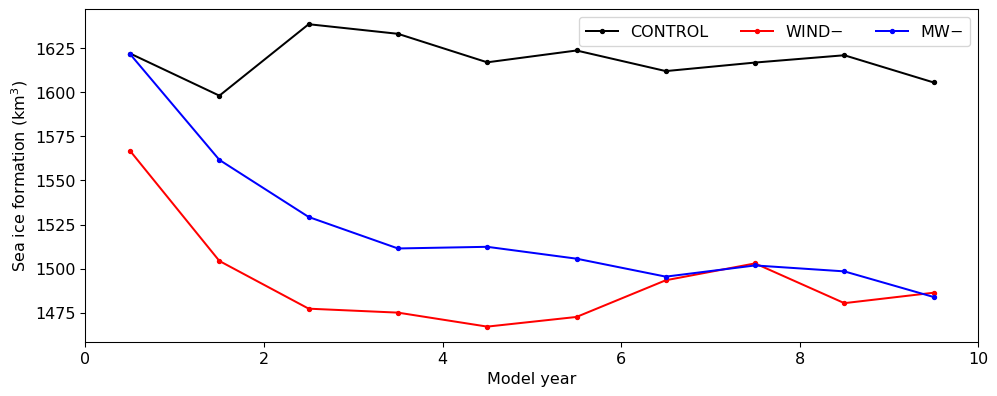

In [10]:
plt.figure(figsize=(12, 4.5))

for ekey in ekeys:
    e = exptdict[ekey]
    plt.plot(
        np.arange(0.5, 10), (yearly_sum((e['ice_growth'].where(shelf_mask == 1).sel(
            xt_ocean=slice(-198, -160), yt_ocean=slice(-79, -71))) /
                                        100 * area_t).sum(
            ['xt_ocean', 'yt_ocean']))/1e9,
        color=e['col'], marker='o', label=e['expt_str'])  # in km3
plt.legend(ncol=3)
plt.xlim(0, 10)
plt.xlabel('Model year')
plt.ylabel('Sea ice formation (km$^3$)')

plt.savefig(path_plots + 'FigS8.png', dpi=300, bbox_inches="tight")

plt.show()